(0, 0) (0.0001, 2e-08)
Approximate derivative for f(x) where x = 0 is 0.00019999999999999998
(1, 2) (1.0001, 2.00040002)
Approximate derivative for f(x) where x = 1 is 4.0001999999987845
(2, 8) (2.0001, 8.000800020000002)
Approximate derivative for f(x) where x = 2 is 8.000199999998785
(3, 18) (3.0001, 18.001200020000002)
Approximate derivative for f(x) where x = 3 is 12.000199999998785
(4, 32) (4.0001, 32.00160002)
Approximate derivative for f(x) where x = 4 is 16.000200000016548


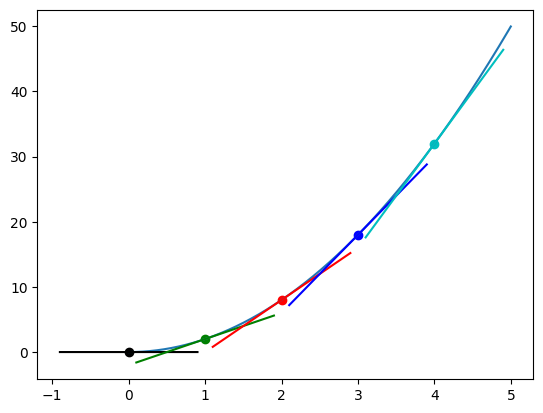

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def f (x):
	return 2*x**2

x = np.arange(0, 5, 0.001)
y = f(x)

plt.plot(x, y)

colors = ['k', 'g', 'r', 'b', 'c']

def approximate_tangent_line (x, approximate_derivative):
    return approximate_derivative * x + b

for i in range(5):

    p2_delta = 0.0001

    x1 = i
    x2 = x1 + p2_delta

    y1 = f(x1)
    y2 = f(x2)

    print((x1, y1), (x2, y2))

    approximate_derivative = (y2-y1)/(x2-x1)
    b = y2 - approximate_derivative*x2

    to_plot = [x1-0.9, x1, x1+0.9]

    plt.scatter(x1, y1, c=colors[i])

    plt.plot([point for point in to_plot],
             [approximate_tangent_line(point, approximate_derivative)
                 for point in to_plot], c=colors[i])

    print('Approximate derivative for f(x)',
        f'where x = {x1} is {approximate_derivative}')

plt.show()

In [31]:
#
# Forward pass
#
x = [1.0, -2.0, 3.0]  # input values
w = [-3.0, -1.0, 2.0]  # weights
b = 1.0  # bias

# Multiplying inputs by weights
xw0 = x[0] * w[0]
xw1 = x[1] * w[1]
xw2 = x[2] * w[2]

# Adding weighted inputs and a bias
z = xw0 + xw1 + xw2 + b

# ReLU activation function
y = max(z, 0)

#
# Backward pass
#
# The derivative from the next layer
dvalue = 1.0

# Derivative of ReLU and the chain rule
drelu_dz = dvalue * (1. if z > 0 else 0.)

#print(drelu_dz)

# Partial derivatives of the sum, the chain rule
dsum_dxw0 = 1
dsum_dxw1 = 1
dsum_dxw2 = 1
dsum_db = 1

drelu_dxw0 = drelu_dz * dsum_dxw0
drelu_dxw1 = drelu_dz * dsum_dxw1
drelu_dxw2 = drelu_dz * dsum_dxw2
drelu_db = drelu_dz * dsum_db

#print(drelu_dxw0, drelu_dxw1, drelu_dxw2, drelu_db)

# Partial derivatives of the multiplication, the chain rule
dmul_dx0 = w[0]
dmul_dw0 = x[0]

dmul_dx1 = w[1]
dmul_dw1 = x[1]

dmul_dx2 = w[2]
dmul_dw2 = x[2]

drelu_dx0 = drelu_dxw0 * dmul_dx0
drelu_dw0 = drelu_dxw0 * dmul_dw0

drelu_dx1 = drelu_dxw1 * dmul_dx1
drelu_dw1 = drelu_dxw0 * dmul_dw1

drelu_dx2 = drelu_dxw2 * dmul_dx2
drelu_dw2 = drelu_dxw0 * dmul_dw2

#print(drelu_dx0, drelu_dw0, drelu_dx1, drelu_dw1, drelu_dx2, drelu_dw2)

# Simplification/optimization

drelu_dx0 = dvalue * (1. if z > 0 else 0.) * w[0]
drelu_dw0 = dvalue * (1. if z > 0 else 0.) * x[0]

drelu_dx1 = dvalue * (1. if z > 0 else 0.) * w[1]
drelu_dw1 = dvalue * (1. if z > 0 else 0.) * x[1]

drelu_dx2 = dvalue * (1. if z > 0 else 0.) * w[2]
drelu_dw2 = dvalue * (1. if z > 0 else 0.) * x[2]

drelu_db = dvalue * (1. if z > 0 else 0.)

#print(drelu_dx0, drelu_dw0, drelu_dx1, drelu_dw1, drelu_dx2, drelu_dw2)

dx = [drelu_dx0, drelu_dx1, drelu_dx2]  # gradients on inputs
dw = [drelu_dw0, drelu_dw1, drelu_dw2]  # gradients on weights
db = drelu_db  # gradient on bias...just 1 bias here

print(dx, dw, db)

# Adjust weights/bias

w[0] += -0.001 * dw[0]
w[1] += -0.001 * dw[1]
w[2] += -0.001 * dw[2]
b += -0.001 * db

print(w, b)

#
# Another forward pass
#
# Multiplying inputs by weights
xw0 = x[0] * w[0]
xw1 = x[1] * w[1]
xw2 = x[2] * w[2]

# Adding
z = xw0 + xw1 + xw2 + b

# ReLU activation function
y = max(z, 0)
print(y)

[-3.0, -1.0, 2.0] [1.0, -2.0, 3.0] 1.0
[-3.001, -0.998, 1.997] 0.999
5.985


In [13]:
import numpy as np

# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([[1., 1., 1.],
                    [2., 2., 2.],
                    [3., 3., 3.]])

# We have 3 sets of weights - one set for each neuron
# we have 4 inputs, thus 4 weights
# recall that we keep weights transposed
weights = np.array([[0.2, 0.8, -0.5, 1],
                    [0.5, -0.91, 0.26, -0.5],
                    [-0.26, -0.27, 0.17, 0.87]]).T

# sum weights of given input
# and multiply by the passed-in gradient for this neuron
dinputs = np.dot(dvalues, weights.T)

print(dinputs)

[[ 0.44 -0.38 -0.07  1.37]
 [ 0.88 -0.76 -0.14  2.74]
 [ 1.32 -1.14 -0.21  4.11]]


In [21]:
import numpy as np

# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([[1., 1., 1.],
                    [2., 2., 2.],
                    [3., 3., 3.]])

# We have 3 sets of inputs - samples
inputs = np.array([[1, 2, 3, 2.5],
                    [2., 5., -1., 2],
                    [-1.5, 2.7, 3.3, -0.8]])


dweights = np.dot(inputs.T, dvalues)

print(dvalues.shape, inputs.shape)

print(dweights)

(3, 3) (3, 4)
[[ 0.5  0.5  0.5]
 [20.1 20.1 20.1]
 [10.9 10.9 10.9]
 [ 4.1  4.1  4.1]]


In [25]:
import numpy as np

# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([[1., 1., 1.],
                    [2., 2., 2.],
                    [3., 3., 3.]])

# One bias for each neuron
# biases are the row vector with a shape (1, neurons)
biases = np.array([[2, 3, 0.5]])

# dbiases - sum values, do this over samples (first axis), keepdims
# since this by default will produce a plain list -
# we explained this in the chapter 4
dbiases = np.sum(dvalues, axis=0, keepdims=True)

print(dbiases)

[[6. 6. 6.]]


In [28]:
import numpy as np

# Example layer output
z = np.array([[1, 2, -3, -4],
            [2, -7, -1, 3],
            [-1, 2, 5, -1]])

dvalues = np.array([[1, 2, 3, 4],
                    [5, 6, 7, 8],
                    [9, 10, 11, 12]])

# ReLU activation's derivative
# with the chain rule applied
drelu = dvalues.copy()
drelu[z <= 0] = 0

print(drelu)

[[ 1  2  0  0]
 [ 5  0  0  8]
 [ 0 10 11  0]]


In [2]:
import numpy as np

# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([[1., 1., 1.],
                    [2., 2., 2.],
                    [3., 3., 3.]])

# We have 3 sets of inputs - samples
inputs = np.array([[1, 2, 3, 2.5],
                    [2., 5., -1., 2],
                    [-1.5, 2.7, 3.3, -0.8]])

# We have 3 sets of weights - one set for each neuron
# we have 4 inputs, thus 4 weights
# recall that we keep weights transposed
weights = np.array([[0.2, 0.8, -0.5, 1],
                    [0.5, -0.91, 0.26, -0.5],
                    [-0.26, -0.27, 0.17, 0.87]]).T

# One bias for each neuron
# biases are the row vector with a shape (1, neurons)
biases = np.array([[2, 3, 0.5]])

# Forward pass
layer_outputs = np.dot(inputs, weights) + biases # Dense layer
relu_outputs = np.maximum(0, layer_outputs) # ReLU activation

# Let's optimize and test backpropagation here
# ReLU activation - simulates derivative with respect to input values
# from next layer passed to current layer during backpropagation
drelu = relu_outputs.copy()
drelu[layer_outputs <= 0] = 0

# Dense layer
# dinputs - multiply by weight
dinputs = np.dot(drelu, weights.T)
# dweights - multiply by inputs
dweights = np.dot(inputs.T, drelu)
# dbiases - sum values, do this over samples (first axis), keepdims
# since this by default will produce a plain list -
# we explained this in the chapter 4
dbiases = np.sum(drelu, axis=0, keepdims=True)

# Update parameters
weights += -0.001 * dweights
biases += -0.001 * dbiases

print(weights)
print(biases)

[[ 0.179515   0.5003665 -0.262746 ]
 [ 0.742093  -0.9152577 -0.2758402]
 [-0.510153   0.2529017  0.1629592]
 [ 0.971328  -0.5021842  0.8636583]]
[[1.98489  2.997739 0.497389]]


In [1]:
import numpy as np

softmax_output = [0.7, 0.1, 0.2]

softmax_output = np.array(softmax_output).reshape(-1, 1)

print(np.diagflat(softmax_output) - np.dot(softmax_output, softmax_output.T))

[[ 0.21 -0.07 -0.14]
 [-0.07  0.09 -0.02]
 [-0.14 -0.02  0.16]]


In [1]:
starting_learning_rate = 1.
learning_rate_decay = 0.1

for step in range(20):
    learning_rate = starting_learning_rate * (1. / (1 + learning_rate_decay * step))
    print(learning_rate)

1.0
0.9090909090909091
0.8333333333333334
0.7692307692307692
0.7142857142857143
0.6666666666666666
0.625
0.588235294117647
0.5555555555555556
0.5263157894736842
0.5
0.47619047619047616
0.45454545454545453
0.4347826086956522
0.41666666666666663
0.4
0.3846153846153846
0.37037037037037035
0.35714285714285715
0.3448275862068965


In [1]:
weights = [[0.2, 0.8, -0.5, 1],  # now we have 3 sets of weights
           [0.5, -0.91, 0.26, -0.5],
           [-0.26, -0.27, 0.17, 0.87]]

dL1 = []  # array of partial derivatives of L1 regularization

for neuron in weights:

    neuron_dL1 = []  # derivatives related to one neuron

    for weight in neuron:
        if weight >= 0:
            neuron_dL1.append(1)
        else:
            neuron_dL1.append(-1)

    dL1.append(neuron_dL1)

print(dL1)


[[1, 1, -1, 1], [1, -1, 1, -1], [-1, -1, 1, 1]]


In [2]:
import numpy as np

weights = np.array([[0.2, 0.8, -0.5, 1],
                    [0.5, -0.91, 0.26, -0.5],
                    [-0.26, -0.27, 0.17, 0.87]])

dL1 = np.ones_like(weights)

dL1[weights < 0] = -1

print(dL1)


[[ 1.  1. -1.  1.]
 [ 1. -1.  1. -1.]
 [-1. -1.  1.  1.]]


In [18]:
import random

dropout_rate = 0.5

# Example output containing 10 values
example_output = [0.27, -1.03, 0.67, 0.99, 0.05,
                -0.37, -2.01, 1.13, -0.07, 0.73]

# Repeat as long as necessary
while True:

    # Randomly choose index and set value to 0
    index = random.randint(0, len(example_output) - 1)
    example_output[index] = 0

    # We might set an index that already is zeroed
    # There are different ways of overcoming this problem,
    # for simplicity we count values that are exactly 0
    # while it's extremely rare in real model that weights
    # are exactly 0, this is not the best method for sure
    dropped_out = 0

    for value in example_output:
        if value == 0:
            dropped_out += 1

    # If required number of outputs is zeroed - leave the loop
    if dropped_out / len(example_output) >= dropout_rate:
        break

print(example_output)

[0, 0, 0, 0.99, 0.05, 0, -2.01, 1.13, 0, 0.73]


In [20]:
import numpy as np

dropout_rate = 0.3

example_output = np.array([0.27, -1.03, 0.67, 0.99, 0.05,
                        	-0.37, -2.01, 1.13, -0.07, 0.73])

example_output *= np.random.binomial(1, 1-dropout_rate, example_output.shape)

print(example_output)

[ 0.   -1.03  0.67  0.99  0.   -0.   -2.01  1.13 -0.07  0.  ]


In [83]:
import numpy as np

dropout_rate = 0.5

example_output = np.array([0.27, -1.03, 0.67, 0.99, 0.05, -0.37, -2.01, 1.13, -0.07, 0.73])

print(f'sum initial {sum(example_output)}')

sums = []

for i in range(10000):
    example_output2 = example_output * np.random.binomial(1, 1 - dropout_rate, example_output.shape) / (1 - dropout_rate)
    sums.append(sum(example_output2))

print(f'mean sum: {np.mean(sums)}')


sum initial 0.36000000000000015
mean sum: 0.3951120000000002


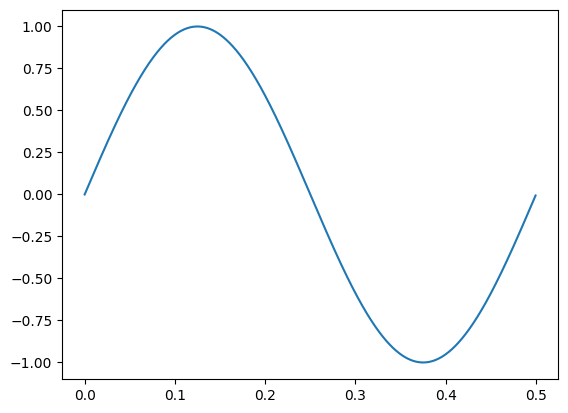

In [10]:
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import sine_data

nnfs.init()

X, y = sine_data()

plt.plot(X, y)
plt.show()

In [1]:
from zipfile import ZipFile
import os
import urllib
import urllib.request

URL = 'https://nnfs.io/datasets/fashion_mnist_images.zip'
FILE = 'fashion_mnist_images.zip'
FOLDER = 'fashion_mnist_images'

if not os.path.isfile(FILE):
    print(f'Downloading {URL} and saving as {FILE}...')
    urllib.request.urlretrieve(URL, FILE)

print('Unzipping images...')

with ZipFile(FILE) as zip_images:
    zip_images.extractall(FOLDER)

print('Done!')

Unzipping images...
Done!


In [1]:
import os

labels = os.listdir('fashion_mnist_images/train')
print(labels)

files = os.listdir('fashion_mnist_images/train/0')
print(files[:10])
print(len(files))

['9', '0', '7', '6', '1', '8', '4', '3', '2', '5']
['3975.png', '1804.png', '4968.png', '1810.png', '3961.png', '0298.png', '1186.png', '3949.png', '3791.png', '4798.png']
6000


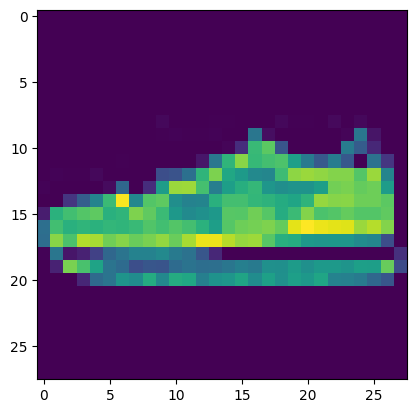

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(linewidth=200)

image_data = cv2.imread('fashion_mnist_images/train/7/0003.png',
                          cv2.IMREAD_UNCHANGED)
#print(image_data)

plt.imshow(image_data)
plt.show()

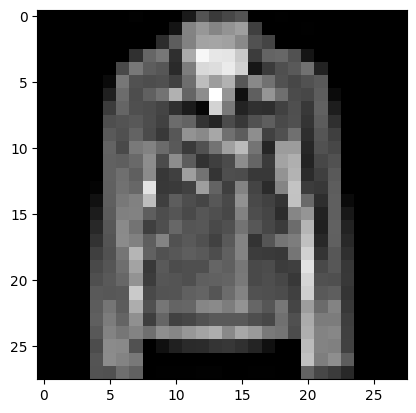

In [16]:
import matplotlib.pyplot as plt, cv2

image_data = cv2.imread('fashion_mnist_images/train/4/0011.png', cv2.IMREAD_UNCHANGED)
plt.imshow(image_data, cmap='gray')
plt.show()